# Ethan's Cleaning Notebook — Sound Sense

This notebook takes the merged dataset and produces a clean, model-ready file manifest based on our EDA findings. Cleaning here means: removing classes and sources the team decided to exclude, quarantining unusable audio files, and saving the surviving file list for the preprocessing pipeline. Actual MFCC and feature extraction happens in the pipeline step — not here.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

# Notebook lives in cleaning/ — BASE_PATH points to repo root
BASE_PATH    = '..'
OUTPUTS_PATH = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUTS_PATH, exist_ok=True)

DATASET_PATH = '/Users/sa27/Downloads/Emotions'

EMOTION_FOLDERS = ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Suprised']

FOLDER_TO_LABEL = {
    'Angry':     'angry',
    'Disgusted': 'disgusted',
    'Fearful':   'fearful',
    'Happy':     'happy',
    'Neutral':   'neutral',
    'Sad':       'sad',
    'Suprised':  'surprised',
}

# Same source-detection regex as the EDA
def detect_source(name):
    if re.match(r'^(OAF_|YAF_|OA_)', name):          return 'TESS'
    if re.match(r'^\d+-\d+-', name):                return 'RAVDESS'
    if re.match(r'^\d{4}_[A-Z]', name):              return 'CREMA-D'
    if re.match(r'^(sa|su|[adfhn])\d+\.wav$', name): return 'SAVEE'
    return 'other'

file_paths, labels = [], []

for folder_name in EMOTION_FOLDERS:
    folder_path = os.path.join(DATASET_PATH, folder_name)
    if not os.path.isdir(folder_path):
        print(f'  WARNING: folder not found: {folder_path}')
        continue
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    label     = FOLDER_TO_LABEL[folder_name]
    for f in wav_files:
        file_paths.append(os.path.join(folder_path, f))
        labels.append(label)

df = pd.DataFrame({'file_path': file_paths, 'emotion': labels})
df['filename'] = df['file_path'].apply(os.path.basename)
df['source']   = df['filename'].apply(detect_source)

print(f'Starting file count : {len(df):,}')
print(f'Emotions            : {sorted(df["emotion"].unique())}')
print(f'Sources             : {sorted(df["source"].unique())}')
print()
print(df.groupby(['emotion', 'source']).size().unstack(fill_value=0))

Starting file count : 12,798
Emotions            : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Sources             : ['CREMA-D', 'RAVDESS', 'SAVEE', 'TESS']

source     CREMA-D  RAVDESS  SAVEE  TESS
emotion                                 
angry         1271      376    120   400
disgusted     1271      192      0   400
fearful       1271      376      0   400
happy         1271      376    120   400
neutral       1087      188    120   400
sad           1271      376    120   400
surprised        0      192      0   400


## 3. Drop the SAVEE source

Based on our EDA we decided as a team to remove all SAVEE files from the dataset. Two reasons drove this:

1. **Mislabeled by folder.** SAVEE files were placed across emotion folders by speaker, not by emotion — meaning a file in `Angry/` might actually be `sa14.wav` (sad). Trusting the folder label would poison the training set with ~480 mislabeled examples.

2. **Small contribution.** SAVEE is the smallest source (~480 files, ~3.7% of the dataset). Even after correcting labels from filenames, the return isn't worth the risk. We drop it entirely and log the removal.

In [2]:
savee_mask   = df['source'] == 'SAVEE'
savee_count  = savee_mask.sum()

df = df[~savee_mask].copy()

print(f'SAVEE files removed : {savee_count:,}')
print(f'Remaining files     : {len(df):,}')

SAVEE files removed : 480
Remaining files     : 12,318


## 4. Drop the Surprised class

Based on our EDA we decided as a team to exclude the `surprised` emotion from training and modeling. The reason is severe class imbalance:

- `surprised` has ~592 files — only ~4.6% of the full dataset
- Every other class has 1,795–2,167 files — a 3.7x imbalance ratio

The imbalance exists because CREMA-D — the largest corpus at ~58% of the data — has no surprise category. A model trained on this imbalance would almost never predict `surprised` even when it should, inflating overall accuracy while producing near-zero recall for that class. We train on the 6 balanced emotions only.

In [3]:
surprised_mask  = df['emotion'] == 'surprised'
surprised_count = surprised_mask.sum()

df = df[~surprised_mask].copy()

print(f'Surprised files removed : {surprised_count:,}')
print(f'Remaining files         : {len(df):,}')
print(f'Remaining emotions      : {sorted(df["emotion"].unique())}')

Surprised files removed : 592
Remaining files         : 11,726
Remaining emotions      : ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad']


## 5. Quarantine bad audio files

Even after dropping excluded sources and classes, individual files can be unusable:

- **Failed to load** — corrupted file, missing header, or access error
- **Too short (< 0.5s)** — not enough audio to extract meaningful features
- **Anomalously long (> mean + 3 std)** — likely a metadata or labeling error; outliers this extreme would distort padding decisions and waste memory

We read metadata for every surviving file using `soundfile.info()` (no full decode needed), flag the bad ones, remove them from the working set, and save them to a CSV so every removal is traceable.

In [4]:
print(f'Reading metadata for {len(df):,} files...')

durations    = []
sample_rates = []
load_errors  = []

for path in df['file_path']:
    try:
        info = sf.info(path)
        durations.append(info.frames / info.samplerate)
        sample_rates.append(info.samplerate)
        load_errors.append(False)
    except Exception:
        durations.append(np.nan)
        sample_rates.append(np.nan)
        load_errors.append(True)

df['duration_sec'] = durations
df['sample_rate']  = sample_rates
df['load_error']   = load_errors

print('Done.\n')

# ── Flag each failure category ────────────────────────────────────────────
failed    = df[df['load_error']]
too_short = df[~df['load_error'] & (df['duration_sec'] < 0.5)]

mean_dur = df['duration_sec'].mean()
std_dur  = df['duration_sec'].std()
long_threshold = mean_dur + 3 * std_dur
too_long  = df[~df['load_error'] & (df['duration_sec'] > long_threshold)]

print(f'Failed to load              : {len(failed):,}')
print(f'Too short (< 0.5s)          : {len(too_short):,}')
print(f'Anomalously long (> {long_threshold:.2f}s) : {len(too_long):,}')

# ── Build quarantine list ─────────────────────────────────────────────────
quarantine_records = []
for _, row in failed.iterrows():
    quarantine_records.append({
        'file_path': row['file_path'], 'emotion': row['emotion'],
        'source': row['source'], 'reason': 'failed to load'
    })
for _, row in too_short.iterrows():
    quarantine_records.append({
        'file_path': row['file_path'], 'emotion': row['emotion'],
        'source': row['source'],
        'reason': f'too short ({row["duration_sec"]:.3f}s < 0.5s)'
    })
for _, row in too_long.iterrows():
    quarantine_records.append({
        'file_path': row['file_path'], 'emotion': row['emotion'],
        'source': row['source'],
        'reason': f'too long ({row["duration_sec"]:.2f}s > {long_threshold:.2f}s)'
    })

quarantine_df = pd.DataFrame(quarantine_records)
quarantine_out = os.path.join(OUTPUTS_PATH, 'quarantined_files.csv')
quarantine_df.to_csv(quarantine_out, index=False)

print(f'\nTotal quarantined           : {len(quarantine_df):,}')
print(f'Saved → {quarantine_out}')

# ── Remove quarantined files from working set ─────────────────────────────
bad_paths = set(quarantine_df['file_path']) if len(quarantine_df) > 0 else set()
df = df[~df['file_path'].isin(bad_paths)].copy()

print(f'\nSurviving files             : {len(df):,}')

Reading metadata for 11,726 files...


Done.

Failed to load              : 0
Too short (< 0.5s)          : 0
Anomalously long (> 5.10s) : 73

Total quarantined           : 73
Saved → ../outputs/quarantined_files.csv

Surviving files             : 11,653


## 6. Final class distribution

With SAVEE removed, Surprised removed, and bad files quarantined, we should now have 6 emotions with no source or quality issues. This step confirms the balance is acceptable before we save the manifest.

Final file count: 11,653

  emotion  count  share_%
    angry   2035    17.46
disgusted   1862    15.98
  fearful   2047    17.57
    happy   2042    17.52
  neutral   1674    14.37
      sad   1993    17.10


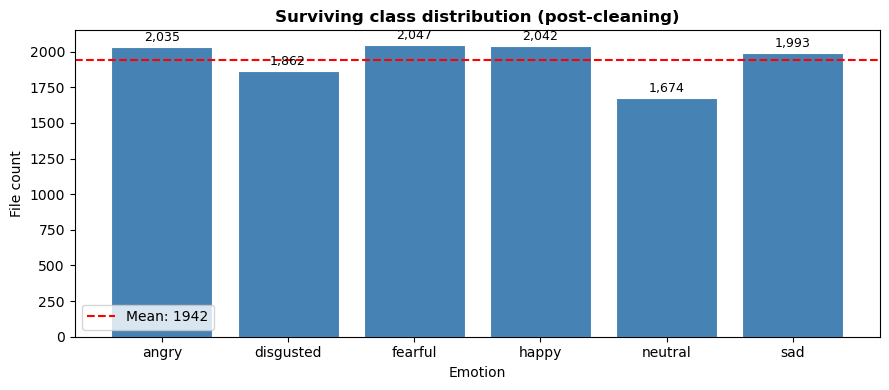

In [5]:
dist = df['emotion'].value_counts().sort_index().reset_index()
dist.columns = ['emotion', 'count']
dist['share_%'] = (dist['count'] / len(df) * 100).round(2)

print(f'Final file count: {len(df):,}\n')
print(dist.to_string(index=False))

# Bar chart of surviving class distribution
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dist['emotion'], dist['count'],
              color='steelblue', edgecolor='white', linewidth=0.8)
for bar, row in zip(bars, dist.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{row.count:,}', ha='center', va='bottom', fontsize=9)
ax.axhline(dist['count'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean: {dist["count"].mean():.0f}')
ax.set_title('Surviving class distribution (post-cleaning)', fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('File count')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save the cleaned manifest

The manifest is the output of this notebook — a CSV of every surviving file with its path, emotion label, source corpus, duration, and sample rate. The preprocessing pipeline reads this manifest and extracts features (MFCCs, RMS, F0) from each path. Nothing here touches the actual audio.

In [6]:
manifest_cols = ['file_path', 'emotion', 'source', 'duration_sec', 'sample_rate']
manifest = df[manifest_cols].reset_index(drop=True)

manifest_out = os.path.join(OUTPUTS_PATH, 'cleaned_manifest.csv')
manifest.to_csv(manifest_out, index=False)

print(f'Manifest saved → {manifest_out}')
print(f'Rows  : {len(manifest):,}')
print(f'Cols  : {list(manifest.columns)}')
print()
manifest.head(8)

Manifest saved → ../outputs/cleaned_manifest.csv
Rows  : 11,653
Cols  : ['file_path', 'emotion', 'source', 'duration_sec', 'sample_rate']



,file_path,emotion,source,duration_sec,sample_rate
0,/Users/sa27/Downloads/Emotions/Angry/03-01-05-...,angry,RAVDESS,3.903896,48000
1,/Users/sa27/Downloads/Emotions/Angry/1022_ITS_...,angry,CREMA-D,2.435750,16000
2,/Users/sa27/Downloads/Emotions/Angry/1037_ITS_...,angry,CREMA-D,3.003000,16000
3,/Users/sa27/Downloads/Emotions/Angry/03-01-05-...,angry,RAVDESS,3.770417,48000
4,/Users/sa27/Downloads/Emotions/Angry/1018_IWL_...,angry,CREMA-D,2.135438,16000
5,/Users/sa27/Downloads/Emotions/Angry/1059_IEO_...,angry,CREMA-D,2.335688,16000
6,/Users/sa27/Downloads/Emotions/Angry/1048_IEO_...,angry,CREMA-D,2.335688,16000
7,/Users/sa27/Downloads/Emotions/Angry/OAF_king_...,angry,TESS,1.662816,24414


In [7]:
savee_removed      = savee_count
surprised_removed  = surprised_count
quarantined_total  = len(quarantine_df)
final_total        = len(df)

print('=== Cleaning summary ===')
print(f'  Started with         : {savee_removed + surprised_removed + quarantined_total + final_total:,} files')
print(f'  Dropped SAVEE        : {savee_removed:,} files')
print(f'  Dropped Surprised    : {surprised_removed:,} files')
print(f'  Quarantined (bad)    : {quarantined_total:,} files')
print(f'  Final manifest       : {final_total:,} files across 6 emotions')

=== Cleaning summary ===
  Started with         : 12,798 files
  Dropped SAVEE        : 480 files
  Dropped Surprised    : 592 files
  Quarantined (bad)    : 73 files
  Final manifest       : 11,653 files across 6 emotions


## 8. Cleaning summary

All decisions below are logged in CSV for reproducibility.

- **Dropped SAVEE (~480 files).** SAVEE folder labels were assigned by speaker, not by emotion — using them would mislabel ~100% of SAVEE clips. The corpus is also the smallest source (~3.7% of data), so the cost of dropping it is low.

- **Dropped Surprised (~592 files non-SAVEE).** CREMA-D has no surprise category, leaving `surprised` at a 3.7x imbalance vs every other class. A model cannot learn this class reliably from so few examples. Excluded from all training and evaluation.

- **Quarantined bad audio files.** Files that failed to load, were shorter than 0.5s, or were anomalously long (> mean + 3 std) were removed from the working set and saved to `outputs/quarantined_files.csv`. See the cell above for exact counts.

- **Final dataset.** See summary output in the cell above for the exact file count across the 6 surviving emotions (Angry, Disgusted, Fearful, Happy, Neutral, Sad). The full list is saved to `outputs/cleaned_manifest.csv` — this is what the preprocessing pipeline reads.

- **What this notebook does NOT do.** No audio is loaded, no features are extracted, no resampling happens here. All of that — `librosa.load(sr=16000)`, MFCC extraction, padding to fixed length — is the preprocessing pipeline's job in Sprint 2.